In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [105]:
# Load Iris dataset
iris = load_iris()

# Features
X = iris.data

# Feature names
print(iris.feature_names)

# First 5 rows
print(X[:5])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [106]:
single_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='single'
)

single_labels = single_model.fit_predict(X)

print(single_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


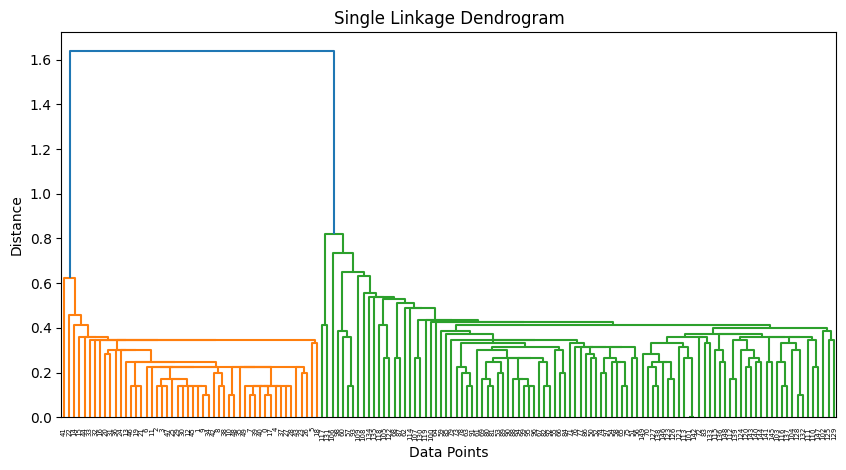

In [107]:
plt.figure(figsize=(10, 5))

single_linkage = linkage(X, method='single')

dendrogram(single_linkage)

plt.title("Single Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("single_dendrogram.png")

plt.show()

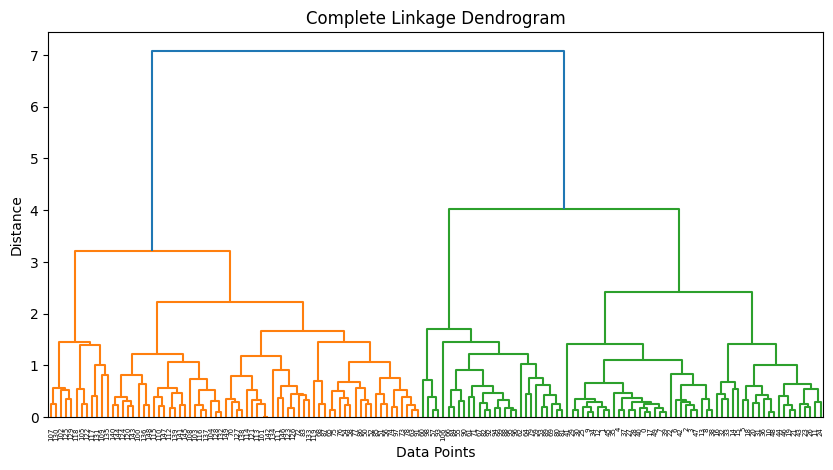

In [108]:
plt.figure(figsize=(10, 5))

complete_linkage = linkage(X, method='complete')

dendrogram(complete_linkage)

plt.title("Complete Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("complete_dendrogram.png")

plt.show()

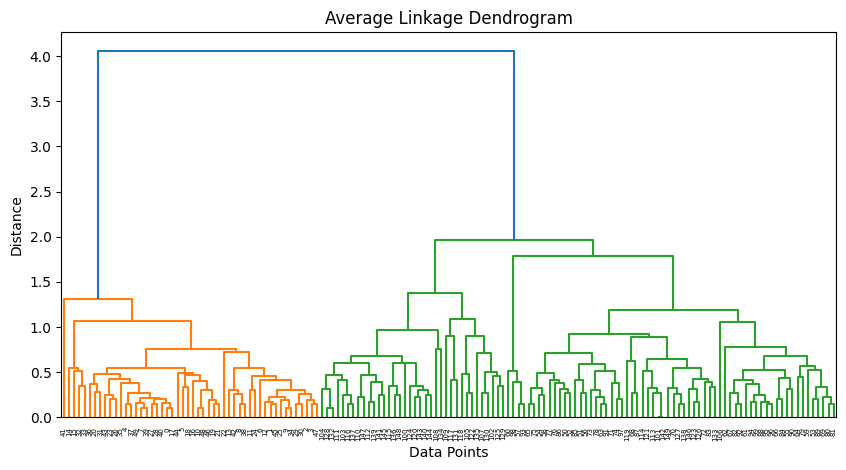

In [109]:
plt.figure(figsize=(10, 5))

average_linkage = linkage(X, method='average')

dendrogram(average_linkage)

plt.title("Average Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("average_dendrogram.png")

plt.show()

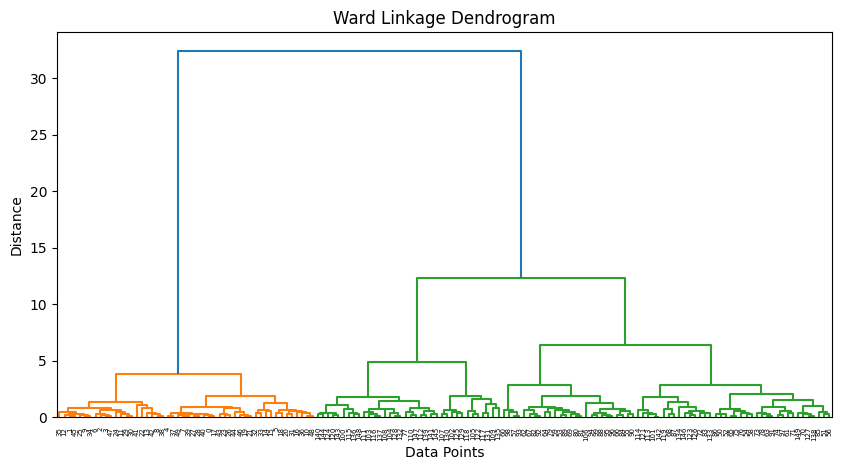

In [110]:
plt.figure(figsize=(10, 5))

ward_linkage = linkage(X, method='ward')

dendrogram(ward_linkage)

plt.title("Ward Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("ward_dendrogram.png")

plt.show()

In [111]:
linkages = ['single', 'complete', 'average', 'ward']

scores = []

for method in linkages:

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append(score)

    print(f"{method} linkage silhouette score: {score:.3f}")

single linkage silhouette score: 0.512
complete linkage silhouette score: 0.514
average linkage silhouette score: 0.554
ward linkage silhouette score: 0.554


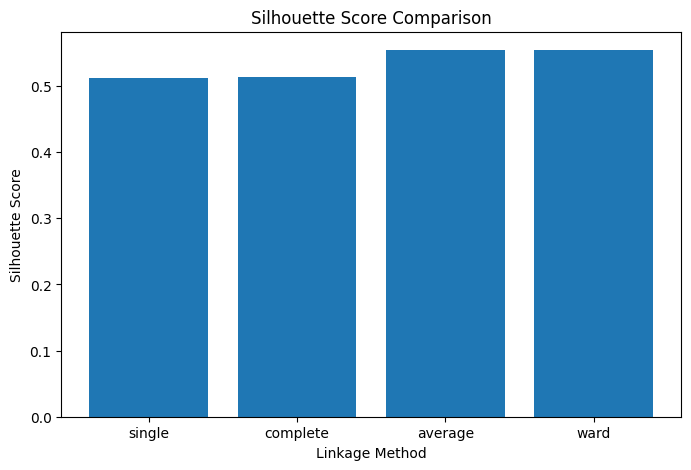

In [112]:
plt.figure(figsize=(8,5))

plt.bar(linkages, scores)

plt.title("Silhouette Score Comparison")
plt.xlabel("Linkage Method")
plt.ylabel("Silhouette Score")

plt.savefig("silhouette_scores.png")

plt.show()

[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]


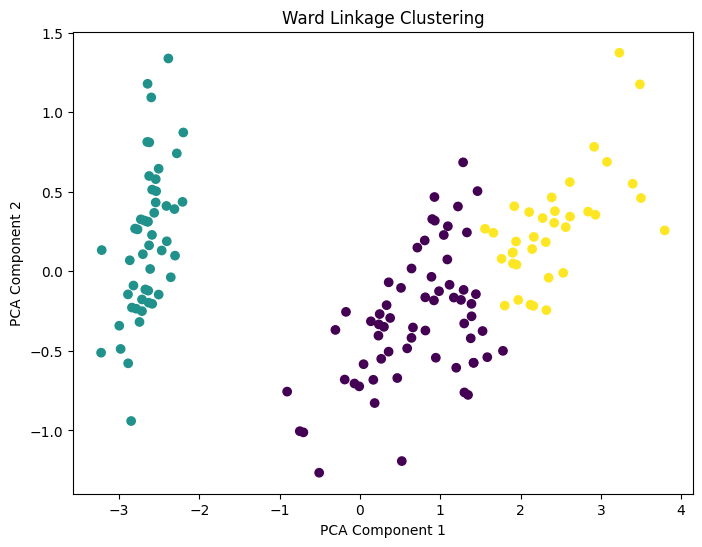

In [113]:
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca[:5])

# Ward clustering model
ward_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

ward_labels = ward_model.fit_predict(X)

# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=ward_labels
)

plt.title("Ward Linkage Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("ward_clusters.png")

plt.show()

In [115]:
from scipy.spatial.distance import pdist, squareform

# Compute pairwise distances
dist_matrix = pdist(X)

# Convert to square matrix
dist_square = squareform(dist_matrix)

print(dist_square[:5, :5])

[[0.         0.53851648 0.50990195 0.64807407 0.14142136]
 [0.53851648 0.         0.3        0.33166248 0.60827625]
 [0.50990195 0.3        0.         0.24494897 0.50990195]
 [0.64807407 0.33166248 0.24494897 0.         0.64807407]
 [0.14142136 0.60827625 0.50990195 0.64807407 0.        ]]


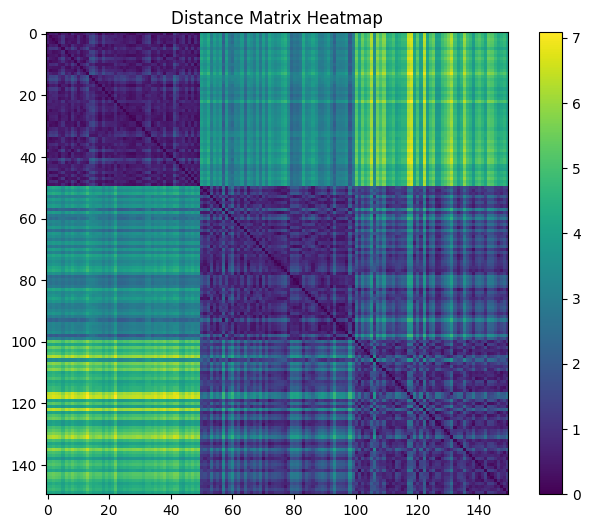

In [116]:
plt.figure(figsize=(8,6))

plt.imshow(dist_square)

plt.title("Distance Matrix Heatmap")

plt.colorbar()

plt.savefig("distance_matrix_heatmap.png")

plt.show()